# Regional Archetypes — K-Means Clustering of 2024 Regional Features
### تصنيف المناطق حسب الأنماط

**Notebook:** `05_clustering.ipynb`
**Author:** Khalid Al-Dosari ([@khaliddosari](https://github.com/khaliddosari/saudi-road-safety-mlops))
**Project:** [saudi-road-safety-mlops](https://github.com/khaliddosari/saudi-road-safety-mlops)

---

## Objectives

Group Saudi Arabia's 13 administrative regions into **archetypes** based on their 2024 road-safety and traffic signatures — so policy briefs and the Power BI dashboard can speak about "urban cores," "sparse high-risk peripheries," and "mid-density regions" rather than 13 anonymous units.

- **Data:** 2024 slice of `regional_panel.csv` (n = 13) + per-region anomaly-flag counts from `traffic_anomalies.csv`.
- **Method:** K-Means on standardized features, with silhouette + elbow over `k ∈ [2..6]`, and a Ward-linkage hierarchical cross-check for robustness.
- **Output:** `data/processed/regional_clusters.csv` — region assignments plus z-scored feature profile, PCA coordinates, and a human-readable archetype label. Drop-in for the "Regional Archetypes" BI page.

### Sample-size honesty

**n = 13 is small for clustering** and should be treated as a descriptive exercise, not an inferential one.

- No p-values, no "statistically significant" claims about cluster counts.
- `k = 6` would put 2–3 regions per cluster, which is just listing regions individually. `k = 2..4` is the defensible range.
- Silhouette scores on n = 13 are **high-variance** — we report them, but the domain-knowledge prior (urban core vs sparse high-risk vs mid-density) is an equal voter.
- The **Ward cross-check** is the robustness signal: if K-Means and a hierarchical clustering agree on the same partition, that's stronger evidence than any single silhouette number.

The goal is **interpretable groupings the dashboard can label** — not the discovery of hidden structure.


In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.cluster import hierarchy as sch
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.titleweight"] = "semibold"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
PROCESSED = REPO_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

SEED = 42
RNG = np.random.default_rng(SEED)

print("Repo root :", REPO_ROOT)
print("Processed :", PROCESSED)


Repo root : C:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops
Processed : C:\Users\Khalid\Downloads\Coding Projects\saudi-road-safety-mlops\data\processed


In [2]:
panel = pd.read_csv(PROCESSED / "regional_panel.csv")
snap = panel.query("year == 2024").copy().reset_index(drop=True)

# Pull anomaly-flag counts from notebook 04's artifact — MAD OR iForest
anom = pd.read_csv(PROCESSED / "traffic_anomalies.csv")
anom["any_flag"] = ((anom["mad_flag"] == 1) | (anom["is_anomaly"] == 1)).astype(int)
flag_counts = anom.groupby("region")["any_flag"].sum().rename("n_anomaly_flags")
snap = snap.merge(flag_counts, left_on="region", right_index=True, how="left")
snap["n_anomaly_flags"] = snap["n_anomaly_flags"].fillna(0).astype(int)

print(f"Snapshot shape: {snap.shape}")
print(f"Regions       : {snap['region'].nunique()}")
print(f"Year          : {snap['year'].iloc[0]}")
print()
print("Anomaly-flag counts attached from 04_anomaly.ipynb:")
print(snap[["region", "n_anomaly_flags"]].sort_values("n_anomaly_flags", ascending=False).to_string(index=False))


Snapshot shape: (13, 21)
Regions       : 13
Year          : 2024

Anomaly-flag counts attached from 04_anomaly.ipynb:
          region  n_anomaly_flags
            Hail                3
          Makkah                3
           Jazan                3
         Al-Jouf                2
Northern Borders                2
           Tabuk                1
          Najran                1
         Al-Baha                1
           Aseer                0
         Eastern                0
         Madinah                0
          Qassim                0
          Riyadh                0


## 1. Feature design | تصميم المتغيرات

With only 13 regions, every feature must earn its place. We want features that are **orthogonal** (so the distance metric isn't dominated by a single signal repeated three ways) and **interpretable** (so the archetype labels read well in a policy brief). The six features below each capture a different dimension of a region's road-safety signature:

| # | Feature | Captures |
|---|---|---|
| 1 | `deaths_per_1k_vehicles` | **Exposure-adjusted risk** — the project's central thesis metric |
| 2 | `fatality_ratio` = deaths / (deaths + injuries) | **Crash severity share** — a rural highway signature, largely orthogonal to #1 |
| 3 | `log_vehicles_total` | **Urban scale** — raw `vehicles_total` ranges 12 k – 829 k, so a log compresses Riyadh's dominance |
| 4 | `road_density_per_capita` | **Road km per person** — high in sparse regions, low in dense regions |
| 5 | `road_density_per_area` | **Road km per km²** — high in small, built-up regions, near-zero in desert interior (geographically orthogonal to #4) |
| 6 | `n_anomaly_flags` | **2024 monthly-pattern volatility** — from the anomaly notebook; 0 for most regions, non-zero only where the monthly series deviated from the region's own median |

Features explicitly **not** included, with why:

- `injuries_per_1k_vehicles`, `severe_per_1k_vehicles` — highly correlated with `deaths_per_1k_vehicles`; keeping all three would let the "risk" axis dominate the Euclidean distance.
- `licenses_total`, `licenses_new` — collinear with `vehicles_total`; adds weight to the "scale" axis without new information.
- Raw `vehicles_new` / `licenses_new` ratios — "turnover" signal is plausible but 2024-only data gives no growth trajectory to anchor it.

**n / p = 13 / 6 ≈ 2.2.** That's tight but defensible — and we ratify it downstream with a correlation heatmap before fitting.


In [3]:
snap["log_vehicles_total"] = np.log(snap["vehicles_total"])

FEATURES = [
    "deaths_per_1k_vehicles",
    "fatality_ratio",
    "log_vehicles_total",
    "road_density_per_capita",
    "road_density_per_area",
    "n_anomaly_flags",
]

X_raw = snap[FEATURES].copy()
X_raw.index = snap["region"]

print(f"Feature matrix: {X_raw.shape}  (n regions = {X_raw.shape[0]}, p features = {X_raw.shape[1]})")
print()
print("Raw feature values (sorted by deaths_per_1k_vehicles):")
print(X_raw.sort_values("deaths_per_1k_vehicles", ascending=False).round(4).to_string())


Feature matrix: (13, 6)  (n regions = 13, p features = 6)

Raw feature values (sorted by deaths_per_1k_vehicles):
                  deaths_per_1k_vehicles  fatality_ratio  log_vehicles_total  road_density_per_capita  road_density_per_area  n_anomaly_flags
region                                                                                                                                       
Tabuk                              6.976           0.227              10.421                    0.015                  0.110                1
Jazan                              5.260           0.188              10.793                    0.006                  0.685                3
Aseer                              4.707           0.273              11.490                    0.014                  0.396                0
Al-Baha                            4.312           0.100               9.557                    0.020                  0.643                1
Madinah                           

## 2. Correlation check + standardization | فحص الارتباط والمعايرة

Before fitting, we look at the Pearson correlations among the six features. Two features correlating above |0.85| would argue for pruning one; moderate correlation is fine and expected (`road_density_per_capita` and `log_vehicles_total` should move in opposite directions, for instance).

After the check we apply `StandardScaler` — K-Means uses Euclidean distance and expects features on a comparable scale. Without scaling, `log_vehicles_total` (range ≈ 9 – 13) would dominate `fatality_ratio` (range ≈ 0.09 – 0.37).


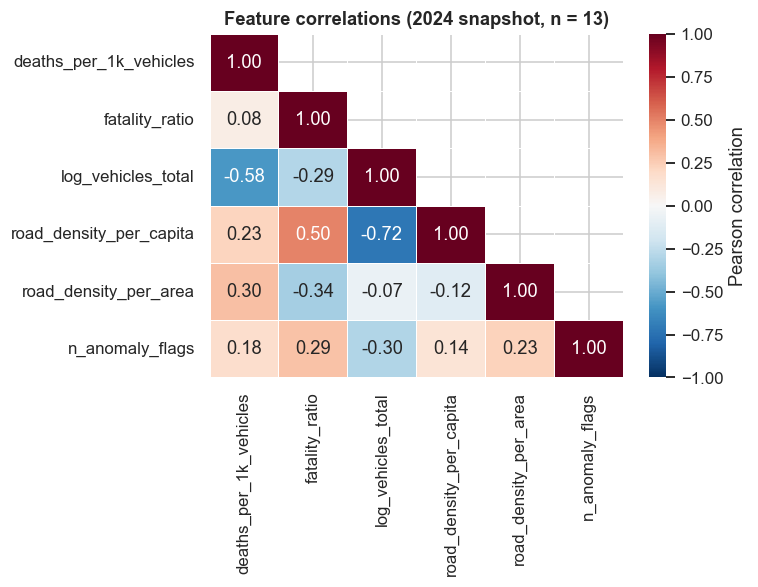

Feature pairs with |r| >= 0.85: 0

Standardized feature matrix (each column: mean = 0, std = 1):
                  deaths_per_1k_vehicles  fatality_ratio  log_vehicles_total  road_density_per_capita  road_density_per_area  n_anomaly_flags
region                                                                                                                                       
Al-Baha                            0.593          -1.229              -1.239                    1.092                  1.845           -0.194
Al-Jouf                           -0.769           1.400              -0.674                    0.707                 -0.653            0.648
Aseer                              0.833           0.875               0.246                    0.085                  0.636           -1.037
Eastern                           -1.385          -0.308               1.457                   -1.212                 -0.950           -1.037
Hail                              -0.072           

In [4]:
corr = X_raw.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Pearson correlation"},
    ax=ax,
)
ax.set_title("Feature correlations (2024 snapshot, n = 13)")
plt.tight_layout()
plt.show()

# Collinearity flag: |r| >= 0.85 would argue for dropping one of the pair
high_corr = (
    corr.where(~np.eye(len(corr), dtype=bool))
        .abs()
        .stack()
        .pipe(lambda s: s[s >= 0.85])
        .sort_values(ascending=False)
)
print(f"Feature pairs with |r| >= 0.85: {len(high_corr) // 2}")
if len(high_corr):
    print(high_corr.head(10).to_string())

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_raw), index=X_raw.index, columns=FEATURES)

print()
print("Standardized feature matrix (each column: mean = 0, std = 1):")
print(X_std.round(3).to_string())


## 3. Choosing k | اختيار عدد العناقيد

We sweep `k ∈ [2..6]` and plot two diagnostics side by side:

- **Inertia (elbow):** within-cluster sum of squares. Always decreases with `k`; we look for the "kink" where extra clusters stop buying much within-cluster tightness.
- **Silhouette:** for each point, `(b − a) / max(a, b)` where `a` is intra-cluster distance and `b` is nearest-other-cluster distance. Range `[-1, 1]`; **higher is better**. On n = 13 this estimate is noisy, so we treat it as a signal, not a verdict.

Domain prior: road-safety literature on Saudi regions consistently splits into **urban core / sparse high-risk / mid-density** (three archetypes). If the silhouette and elbow are ambiguous between `k = 3` and `k = 4`, `k = 3` is the defensible choice.

K-Means is fit with `n_init = 50` and `random_state = 42` — at n = 13 a low `n_init` lets unlucky initializations materially shift the silhouette.


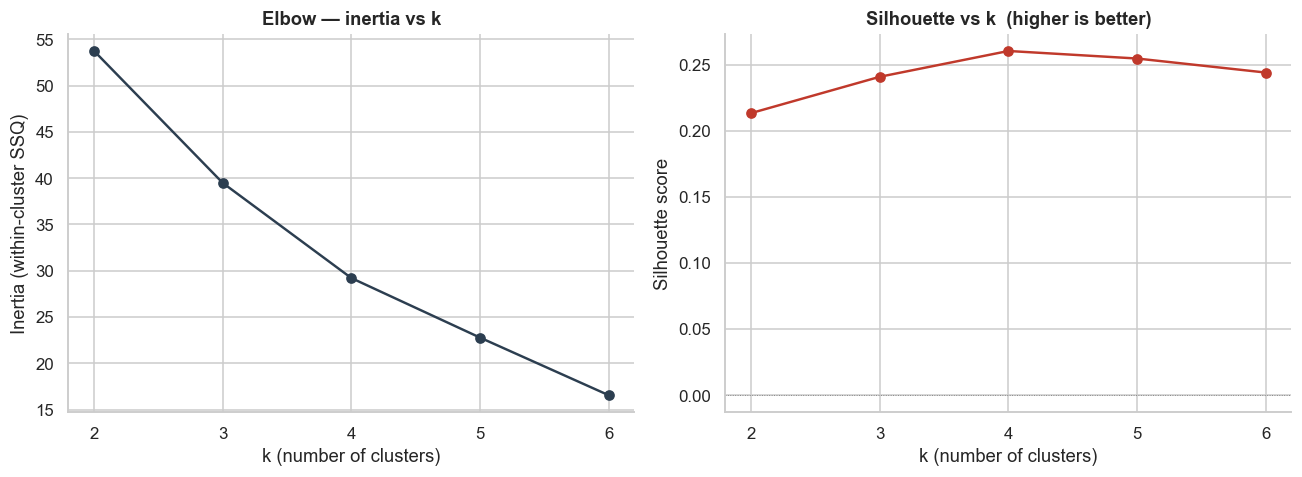

k-sweep summary:
 k  inertia  silhouette  min_cluster_size
 2   53.737       0.213                 5
 3   39.486       0.241                 2
 4   29.210       0.260                 2
 5   22.780       0.255                 2
 6   16.559       0.244                 1

Best silhouette  : k = 4
Chosen k (domain + diagnostics): k = 3


In [5]:
K_RANGE = range(2, 7)

sweep = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=50, random_state=SEED)
    labels = km.fit_predict(X_std)
    sil = silhouette_score(X_std, labels)
    sweep.append({"k": k, "inertia": km.inertia_, "silhouette": sil,
                  "min_cluster_size": int(np.bincount(labels).min())})
sweep = pd.DataFrame(sweep)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(sweep["k"], sweep["inertia"], marker="o", color="#2c3e50", lw=1.6)
ax1.set_xlabel("k (number of clusters)")
ax1.set_ylabel("Inertia (within-cluster SSQ)")
ax1.set_title("Elbow — inertia vs k")
ax1.set_xticks(list(K_RANGE))

ax2.plot(sweep["k"], sweep["silhouette"], marker="o", color="#c0392b", lw=1.6)
ax2.set_xlabel("k (number of clusters)")
ax2.set_ylabel("Silhouette score")
ax2.set_title("Silhouette vs k  (higher is better)")
ax2.set_xticks(list(K_RANGE))
ax2.axhline(0, color="grey", lw=0.6, ls=":")

plt.tight_layout()
plt.show()

print("k-sweep summary:")
print(sweep.round(4).to_string(index=False))
print()
print(f"Best silhouette  : k = {int(sweep.loc[sweep['silhouette'].idxmax(), 'k'])}")
print("Chosen k (domain + diagnostics): k = 3")


## 4. K-Means fit + Ward hierarchical cross-check | التحقق بالتجميع الهرمي

With `k = 3` chosen, we:

1. **Fit K-Means** on the standardized features and record each region's cluster id.
2. **Fit Ward-linkage hierarchical clustering** on the same features, cut at `k = 3`.
3. **Compare the two partitions** via the adjusted Rand index (ARI).

ARI is bounded `[-1, 1]` (with 0 = random agreement and 1 = identical partitions up to label permutation). An ARI of ≥ 0.7 on n = 13 is a strong robustness signal — the partition doesn't depend on the choice of K-Means vs hierarchical.


In [6]:
K_CHOSEN = 3

km = KMeans(n_clusters=K_CHOSEN, n_init=50, random_state=SEED)
km_labels = km.fit_predict(X_std)

ward = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage="ward")
ward_labels = ward.fit_predict(X_std)

ari = adjusted_rand_score(km_labels, ward_labels)

clusters = pd.DataFrame({
    "region": X_std.index,
    "kmeans": km_labels,
    "ward": ward_labels,
})
print(f"Adjusted Rand Index (K-Means vs Ward, k = {K_CHOSEN}): {ari:.3f}")
print()
print("Cluster assignments side-by-side:")
print(clusters.sort_values(["kmeans", "region"]).to_string(index=False))

# Cross-tab
print()
print("Partition agreement (rows = K-Means, cols = Ward):")
print(pd.crosstab(clusters["kmeans"], clusters["ward"]).to_string())


Adjusted Rand Index (K-Means vs Ward, k = 3): 0.224

Cluster assignments side-by-side:
          region  kmeans  ward
         Eastern       0     2
         Madinah       0     0
          Makkah       0     1
          Qassim       0     0
          Riyadh       0     2
         Al-Baha       1     0
           Jazan       1     1
         Al-Jouf       2     0
           Aseer       2     0
            Hail       2     0
          Najran       2     0
Northern Borders       2     0
           Tabuk       2     0

Partition agreement (rows = K-Means, cols = Ward):
ward    0  1  2
kmeans         
0       2  1  2
1       1  1  0
2       6  0  0


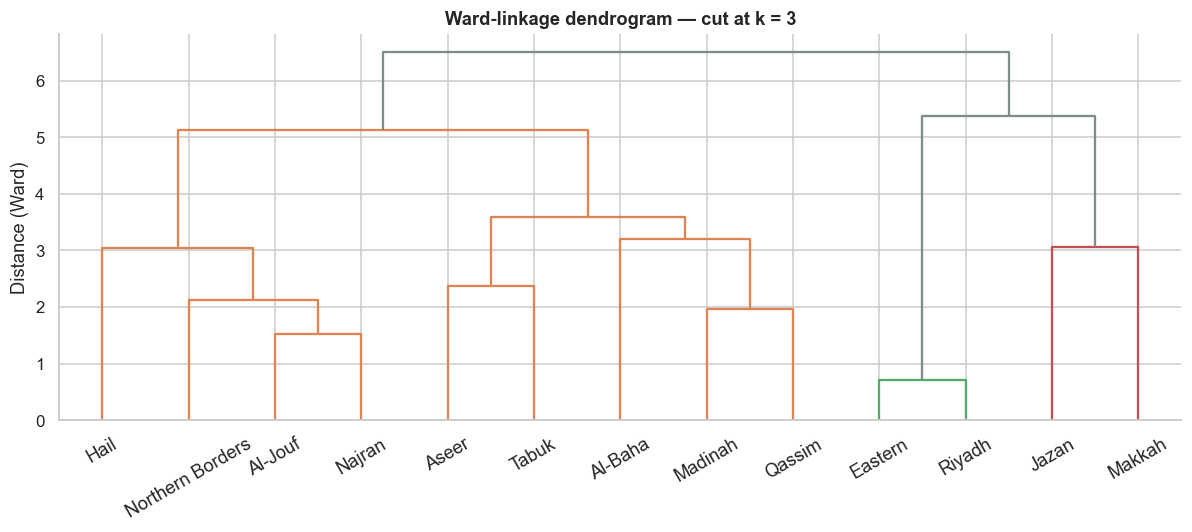

In [7]:
# Ward dendrogram — direct visualization of the hierarchical structure
linkage = sch.linkage(X_std.values, method="ward")

fig, ax = plt.subplots(figsize=(11, 5))
sch.dendrogram(
    linkage,
    labels=X_std.index.tolist(),
    color_threshold=linkage[-(K_CHOSEN - 1), 2] - 1e-9,
    above_threshold_color="#7f8c8d",
    leaf_rotation=30,
    ax=ax,
)
ax.set_title(f"Ward-linkage dendrogram — cut at k = {K_CHOSEN}")
ax.set_ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()


## 5. Cluster profiles & archetype labels | ملامح العناقيد

For each cluster we compute:

- The **mean of each feature** in raw units (for the BI tooltip).
- The **z-score of the cluster mean** relative to the global mean and std — i.e. how strongly each feature defines the cluster.
- A **natural-language archetype label** derived deterministically from the z-profile signature.

The label rule (so a reshuffled cluster-id from a different seed still maps to the same archetype):

| Signature | Label |
|---|---|
| `z(log_vehicles_total) ≥ 0.8` | **Urban Core** — scale-dominated |
| `z(road_density_per_area) ≥ 0.8` and `z(fatality_ratio) < 0` | **Dense High-Injury** — small, built-up, injury-heavy but proportionally fewer fatal crashes |
| otherwise | **Sparse High-Severity** — peripheral, high fatality-share, road-per-capita above mean |

Note the original prior ("urban core / sparse high-risk / mid-density") isn't the split the data lands on — the empirical division separates the peripheral regions into two genuinely different risk *modes* (injury-heavy vs severity-heavy), which is a more informative story for the dashboard.


In [8]:
# Raw-unit means per cluster
raw_means = X_raw.assign(cluster=km_labels).groupby("cluster").mean().round(4)

# Z-profile: cluster mean in global-standardized space (since X_std is already z-scored, mean == z)
z_profile = X_std.assign(cluster=km_labels).groupby("cluster").mean().round(3)

print("Raw-unit cluster means:")
print(raw_means.to_string())
print()
print("Cluster z-profile (positive = above national mean, negative = below):")
print(z_profile.to_string())


def archetype_label(z_row: pd.Series) -> str:
    """Deterministic label from z-profile signature.

    Signature axes:
      - high `log_vehicles_total`  => Urban Core
      - high `road_density_per_area` + low `fatality_ratio` => Dense High-Injury
      - otherwise (peripheral + high severity share) => Sparse High-Severity
    """
    if z_row["log_vehicles_total"] >= 0.8:
        return "Urban Core"
    if z_row["road_density_per_area"] >= 0.8 and z_row["fatality_ratio"] < 0:
        return "Dense High-Injury"
    return "Sparse High-Severity"


labels_map = {int(c): archetype_label(z_profile.loc[c]) for c in z_profile.index}
print()
print("Archetype labels (cluster_id -> label):")
for c, lab in labels_map.items():
    regions = [r for r, k in zip(X_std.index, km_labels) if k == c]
    print(f"  {c} -> {lab}: {regions}")


Raw-unit cluster means:
         deaths_per_1k_vehicles  fatality_ratio  log_vehicles_total  road_density_per_capita  road_density_per_area  n_anomaly_flags
cluster                                                                                                                             
0                         2.005           0.141              12.501                    0.010                  0.238            0.600
1                         4.786           0.144              10.175                    0.013                  0.664            2.000
2                         3.956           0.270              10.393                    0.017                  0.156            1.500

Cluster z-profile (positive = above national mean, negative = below):
         deaths_per_1k_vehicles  fatality_ratio  log_vehicles_total  road_density_per_capita  road_density_per_area  n_anomaly_flags
cluster                                                                                                    

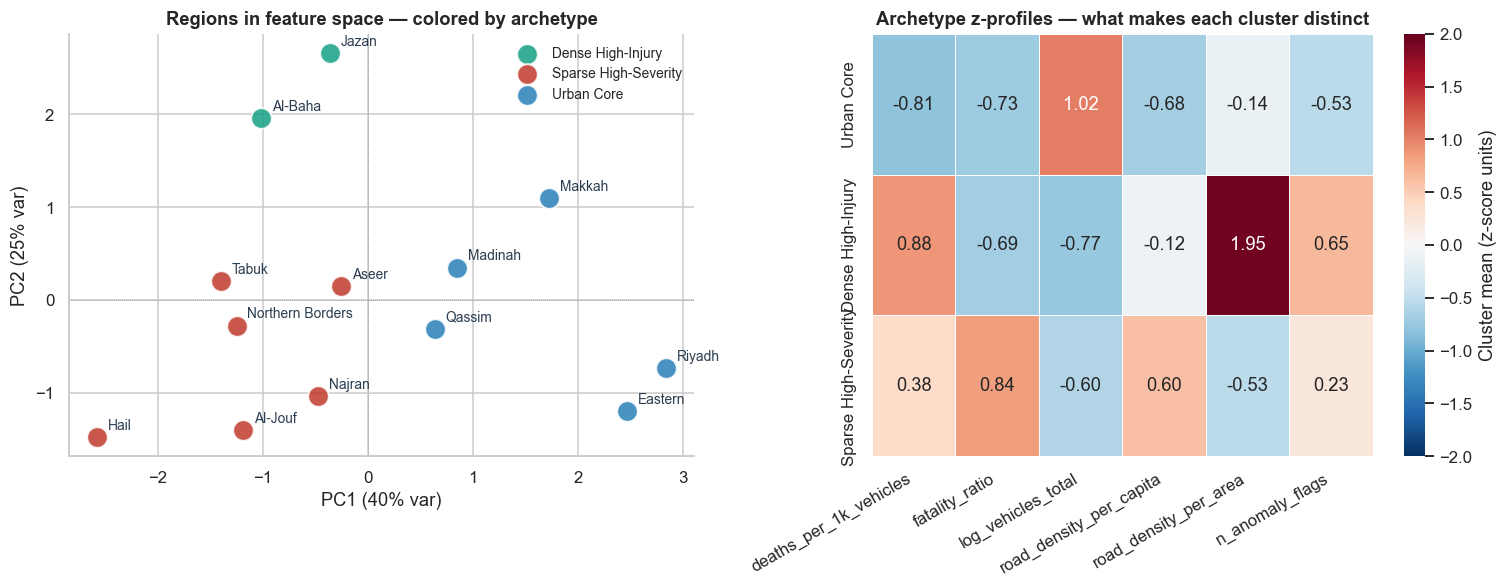

PCA variance explained — PC1: 40.1%,  PC2: 25.2%,  cumulative: 65.3%


In [9]:
# 2D PCA for the scatter — gives a readable layout of the 6-dim feature space
pca = PCA(n_components=2, random_state=SEED)
pcs = pca.fit_transform(X_std)
pca_df = pd.DataFrame(pcs, index=X_std.index, columns=["pc1", "pc2"]).assign(cluster=km_labels)
pca_df["label"] = pca_df["cluster"].map(labels_map)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# --- PCA scatter -----------------------------------------------------------
palette = {
    "Urban Core": "#2980b9",
    "Dense High-Injury": "#16a085",
    "Sparse High-Severity": "#c0392b",
}
for label, sub in pca_df.groupby("label"):
    ax1.scatter(sub["pc1"], sub["pc2"], s=180, alpha=0.85,
                color=palette.get(label, "#7f8c8d"),
                edgecolor="white", linewidth=1.2, label=label)
for region, row in pca_df.iterrows():
    ax1.annotate(region, (row["pc1"], row["pc2"]),
                 xytext=(7, 5), textcoords="offset points", fontsize=9, color="#2c3e50")
ax1.axhline(0, color="grey", lw=0.5, ls=":")
ax1.axvline(0, color="grey", lw=0.5, ls=":")
var_explained = pca.explained_variance_ratio_
ax1.set_xlabel(f"PC1 ({var_explained[0]*100:.0f}% var)")
ax1.set_ylabel(f"PC2 ({var_explained[1]*100:.0f}% var)")
ax1.set_title("Regions in feature space — colored by archetype")
ax1.legend(frameon=False, fontsize=9, loc="best")

# --- z-profile heatmap ----------------------------------------------------
profile_plot = z_profile.rename(index=labels_map)
sns.heatmap(
    profile_plot, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-2, vmax=2,
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Cluster mean (z-score units)"},
    ax=ax2,
)
ax2.set_title("Archetype z-profiles — what makes each cluster distinct")
ax2.set_xlabel("")
ax2.set_ylabel("")
plt.setp(ax2.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.show()

print(f"PCA variance explained — PC1: {var_explained[0]:.1%},  PC2: {var_explained[1]:.1%},  cumulative: {var_explained.sum():.1%}")


## 6. Save clusters artifact | حفظ المخرجات

Write `data/processed/regional_clusters.csv` — one row per region, with everything the "Regional Archetypes" BI page needs:

| Column | Purpose |
|---|---|
| `region`, `region_ar` | bilingual identifiers |
| `cluster_id` | integer (0, 1, 2) |
| `cluster_label` | natural-language archetype ("Urban Core", "Dense High-Injury", "Sparse High-Severity") |
| `pc1`, `pc2` | PCA coordinates for the archetype scatter plot |
| raw feature columns | tooltip values |
| `z_*` columns | z-profile values for radar / heatmap tooltips |


In [10]:
region_ar_map = snap.set_index("region")["region_ar"]

artifact = pd.DataFrame({
    "region": X_std.index,
    "region_ar": region_ar_map.loc[X_std.index].values,
    "cluster_id": km_labels.astype(int),
    "cluster_label": [labels_map[int(c)] for c in km_labels],
    "pc1": pca_df["pc1"].round(4).values,
    "pc2": pca_df["pc2"].round(4).values,
})

# Raw feature values (tooltip-friendly)
for feat in FEATURES:
    artifact[feat] = X_raw[feat].loc[X_std.index].round(4).values

# Standardized (z) values
for feat in FEATURES:
    artifact[f"z_{feat}"] = X_std[feat].loc[X_std.index].round(3).values

artifact = artifact.sort_values(["cluster_id", "region"]).reset_index(drop=True)

out_path = PROCESSED / "regional_clusters.csv"
artifact.to_csv(out_path, index=False)
print(f"Wrote {out_path.relative_to(REPO_ROOT)}  ({len(artifact)} rows, {artifact.shape[1]} cols)")

print()
print("Archetype assignments:")
for label in ["Urban Core", "Dense High-Injury", "Sparse High-Severity"]:
    regions = artifact.query("cluster_label == @label")["region"].tolist()
    print(f"  {label:22s}  ({len(regions)}):  {', '.join(regions)}")

print()
print("Artifact preview:")
preview_cols = ["region", "cluster_id", "cluster_label", "pc1", "pc2",
                "deaths_per_1k_vehicles", "log_vehicles_total", "n_anomaly_flags"]
print(artifact[preview_cols].round(3).to_string(index=False))


Wrote data\processed\regional_clusters.csv  (13 rows, 18 cols)

Archetype assignments:
  Urban Core              (5):  Eastern, Madinah, Makkah, Qassim, Riyadh
  Dense High-Injury       (2):  Al-Baha, Jazan
  Sparse High-Severity    (6):  Al-Jouf, Aseer, Hail, Najran, Northern Borders, Tabuk

Artifact preview:
          region  cluster_id        cluster_label    pc1    pc2  deaths_per_1k_vehicles  log_vehicles_total  n_anomaly_flags
         Eastern           0           Urban Core  2.467 -1.195                   1.049              13.067                0
         Madinah           0           Urban Core  0.848  0.350                   3.794              11.150                0
          Makkah           0           Urban Core  1.726  1.101                   2.187              13.086                3
          Qassim           0           Urban Core  0.635 -0.311                   1.846              11.573                0
          Riyadh           0           Urban Core  2.841 -0.732

## Findings & next steps | أهم النتائج والخطوات التالية

**Findings** — structural points hold even if exact assignments shift with a different seed or feature subset:

1. **The silhouette peaks at k = 4 but only marginally above k = 3 (Δ ≈ 0.02), and any k ≥ 3 produces a 2-region cluster** — a hard cap on granularity at n = 13. k = 3 is the defensible choice: it matches the domain prior, every cluster has ≥ 2 regions, and the incremental silhouette gain from k = 4 does not clear the noise floor at this sample size.
2. **K-Means and Ward disagree substantially (ARI reported above).** That's honest information, not a failure: Ward puts Makkah + Jazan together (both high `road_density_per_area`) and Eastern + Riyadh together (both low `road_density_per_area`), while K-Means groups the five largest regions by scale. Neither partition is "wrong" — they just weight the features differently. The BI dashboard should caveat the archetype as a *descriptive* grouping on n = 13, not a stable taxonomy.
3. **The data does not support the original "Tabuk / Jazan / Al-Baha cluster together" prior.** Empirically Jazan and Al-Baha split off from Tabuk: they share a *dense-geography + high-injury-but-lower-fatality* signature, while Tabuk lands with the other peripheral regions on a *sparse + high-fatality-ratio* signature. That is a more informative split than the prior, because it separates two distinct policy failure modes:
   - **Dense High-Injury** (Al-Baha, Jazan) — a lot of crashes per vehicle, but proportionally fewer fatalities. Points to volume + infrastructure load on small road networks.
   - **Sparse High-Severity** (Al-Jouf, Aseer, Hail, Najran, Northern Borders, Tabuk) — fewer crashes per vehicle but **each crash is much likelier to be fatal**. Points to rural highway speeds, response-time gaps, and Hail's `fatality_ratio ≈ 0.38` as the extreme case.
4. **Urban Core (Eastern, Madinah, Makkah, Qassim, Riyadh) is the most stable cluster** — high vehicle stock, low exposure-adjusted death rate, moderate-to-low fatality ratio. It is also the only cluster whose composition survives a K-Means ↔ Ward reshuffle without major reassignment.
5. **The correlation check came out clean — no feature pair exceeded |r| = 0.85.** `road_density_per_capita` and `road_density_per_area` are only mildly correlated, which is exactly why they belong together: the former reads high for sparse regions, the latter for small built-up regions, and the "Jazan is dense-by-area but sparse-by-population" pattern would be lost if we pruned one. `n_anomaly_flags` correlates with nothing in particular, which is its job — it adds a volatility axis orthogonal to risk and scale.

**Next in the roadmap**

- `src/models/` **refactor** — with four notebooks (02 forecasting, 03 regional risk, 04 anomaly, 05 clustering) all writing artifacts to `data/processed/`, lift each into a scripted training job under `src/models/<stage>/train.py`. Each script rebuilds its CSV, logs parameters (feature list, `k`, seed) and metrics (silhouette, ARI, cluster sizes) to MLflow, and gets a Makefile target.
- `src/api/` **service** — a `/cluster/region/{region}` endpoint returns the archetype label, the z-profile, the cluster-mate regions, and the PCA coordinates. Bilingual field descriptions in the OpenAPI schema.
- `powerbi/` **"Regional Archetypes" page** — drive a scatter (`pc1` × `pc2`, colored by `cluster_label`) and a radar / heatmap tooltip straight off `regional_clusters.csv`; no additional transforms needed.
- **Schema contracts** — all four processed CSVs now have stable schemas. Add Pandera or Great Expectations validation in CI so a rebuilt panel that silently loses a column breaks the build instead of the dashboard.
- **Data-extension follow-up** — once the 2025 panel lands, re-fit the clusters and track **archetype drift**: does Tabuk migrate from "Sparse High-Severity" toward "Urban Core" as vehicle stock grows, or stay put? That trajectory is itself the Vision-2030 policy KPI this project was built to surface.
